## HC3 Human vs. ChatGPT Exploratory Data Analysis

### Load training answers

Run the existing cleaning and splitting notebooks first. Select raw answers using their training question IDs to preserve punctuation and paragraph breaks.

In [26]:
import ast
import re
import string
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent

raw = pd.read_csv(ROOT / "data/hc3_all.csv")
train = pd.read_csv(ROOT / "data/processed/train.csv")
assert train["id"].is_unique
assert set(train["id"]).issubset(set(raw["id"]))
df = raw[raw["id"].isin(train["id"])].copy()
assert len(df) == len(train)

LABELS = ["human", "chatgpt"]
sns.set_theme(style="whitegrid")
print(f"Training question rows: {len(df):,}")
df.head()

Training question rows: 19,093


,id,question,human_answers,chatgpt_answers,index,source
0,0,"Why is every book I hear about a "" NY Times # ...","['Basically there are many categories of "" Bes...",['There are many different best seller lists t...,NaN,reddit_eli5
2,2,Why do we still have SD TV channels when HD lo...,"[""The way it works is that old TV stations got...","[""There are a few reasons why we still have SD...",NaN,reddit_eli5
3,3,Why has nobody assassinated Kim Jong - un He i...,"[""You ca n't just go around assassinating the ...",['It is generally not acceptable or ethical to...,NaN,reddit_eli5
5,5,Why do humans have different colored eyes ? Wh...,['Melanin ! Many of the the first known humans...,['The color of your eyes is determined by the ...,NaN,reddit_eli5
6,6,Why I can not fabricate a religion that preven...,"[""Because you 're a minor and your parents get...",['The First Amendment to the United States Con...,NaN,reddit_eli5


### Expand and label the answers

Convert each question’s answer lists into one row per answer. Remove empty answers and assign labels: human = 0, ChatGPT = 1. The counts show how many answers each group contributes.

In [2]:
parts = []
for column, label in [("human_answers", "human"), ("chatgpt_answers", "chatgpt")]:
    part = df[["id", "source", column]].copy()
    part[column] = part[column].apply(ast.literal_eval)
    part = part.explode(column).rename(columns={column: "text"})
    part["label"] = label
    parts.append(part)

answers = pd.concat(parts, ignore_index=True)
valid = answers["text"].notna() & answers["text"].fillna("").str.strip().ne("")
print(f"Empty or blank answers removed: {(~valid).sum():,}")
answers = answers.loc[valid].reset_index(drop=True)
answers["target"] = answers["label"].map({"human": 0, "chatgpt": 1})
assert answers["text"].map(lambda text: isinstance(text, str)).all()
display(answers["label"].value_counts().rename("answer_count"))
answers.head()

Empty or blank answers removed: 13


label
human      45743
chatgpt    21489
Name: answer_count, dtype: int64

,id,source,text,label,target
0,0,reddit_eli5,"Basically there are many categories of "" Best ...",human,0
1,0,reddit_eli5,"If you 're hearing about it , it 's because it...",human,0
2,0,reddit_eli5,"One reason is lots of catagories . However , h...",human,0
3,2,reddit_eli5,The way it works is that old TV stations got a...,human,0
4,2,reddit_eli5,HD does n't look like anything at all on an SD...,human,0


## Answer Length

### Compare character, word, and sentence counts

Check whether one group writes longer answers. The mean is the average; the median is the middle value and is less affected by very long answers. Characters include spaces, words use letter-based tokens, and sentence boundaries are estimated from punctuation.

character_count                    word_count                   \
                   mean  median min    max       mean median min   max   
label                                                                    
chatgpt         1008.14  1010.0  16   3508     174.16  175.0   2   632   
human            688.05   425.0   9  36793     118.85   74.0   0  5757   

        sentence_count                  
                  mean median min  max  
label                                   
chatgpt           7.07    7.0   1   32  
human             6.65    4.0   1  369

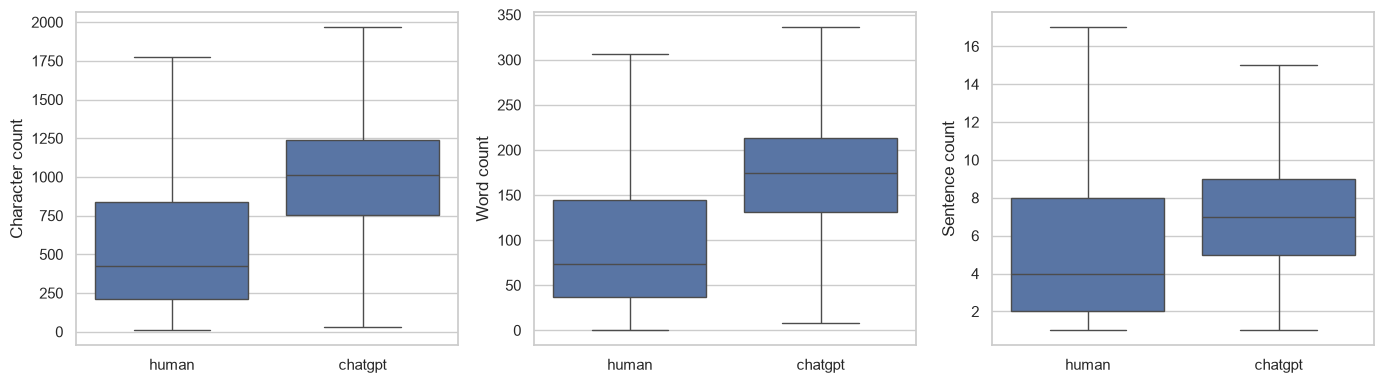

In [3]:
word_pattern = re.compile(r"[^\W\d_]+(?:['’][^\W\d_]+)*", re.UNICODE)
tokens = answers["text"].map(lambda text: word_pattern.findall(text.lower()))

def sentence_count(text):
    pieces = re.split(r"[.!?]+[\"'’”)]*(?:\s+|$)", text.strip())
    return sum(bool(re.search(r"\w", piece)) for piece in pieces)

answers["character_count"] = answers["text"].str.len()
answers["word_count"] = tokens.map(len)
answers["sentence_count"] = answers["text"].map(sentence_count)
length_columns = ["character_count", "word_count", "sentence_count"]
length_summary = answers.groupby("label")[length_columns].agg(["mean", "median", "min", "max"])
display(length_summary.round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, column in zip(axes, length_columns):
    sns.boxplot(data=answers, x="label", y=column, order=LABELS, showfliers=False, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(column.replace("_", " ").capitalize())
plt.tight_layout()
plt.show()

### Read the length plots

The line inside each box is the median; the box contains the middle 50% of answers. Outlier points are hidden, but included in the tables. Large length differences could give the classifier an easy shortcut.

## Vocabulary

### Compare unique words and repetition

Count distinct lowercase words and calculate unique words divided by total words. For example, 60 unique words in a 100-word answer gives a ratio of 0.60.

unique_word_count        unique_word_ratio       
                     mean median              mean median
label                                                    
chatgpt            87.941   88.0             0.531  0.522
human              69.820   54.0             0.722  0.724

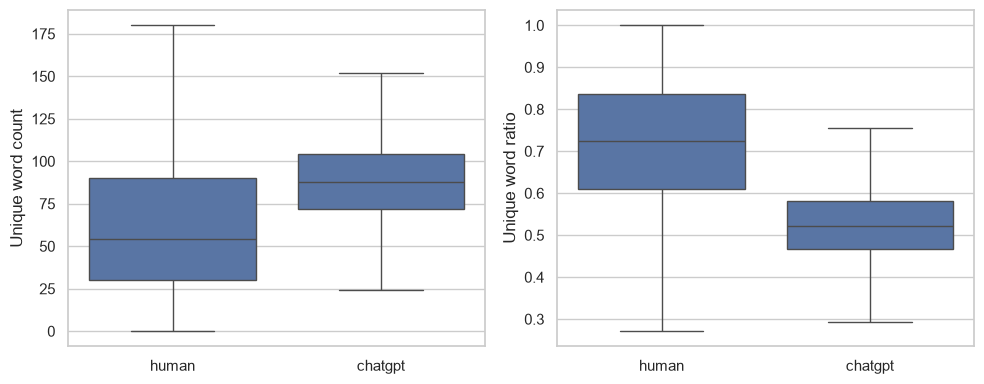

In [25]:
answers["unique_word_count"] = tokens.map(lambda words: len(set(words)))
answers["unique_word_ratio"] = answers["unique_word_count"] / answers["word_count"].replace(0, float("nan"))
vocabulary_columns = ["unique_word_count", "unique_word_ratio"]
display(answers.groupby("label")[vocabulary_columns].agg(["mean", "median"]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, column in zip(axes, vocabulary_columns):
    sns.boxplot(data=answers, x="label", y=column, order=LABELS, showfliers=False, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(column.replace("_", " ").capitalize())
plt.tight_layout()
plt.show()

### Compare the most frequent words

Show the top 15 words in each group. Each bar gives occurrences per 10,000 words, making groups with different amounts of text easier to compare. Common words are kept because they can reveal writing patterns.

,word,count,per_10000_words,label
0,the,285282,524.74,human
1,to,155334,285.72,human
2,a,147308,270.95,human
3,of,129735,238.63,human
4,and,125608,231.04,human
5,is,100481,184.82,human
6,you,89235,164.14,human
7,it,88267,162.36,human
8,in,84020,154.54,human
9,that,81458,149.83,human


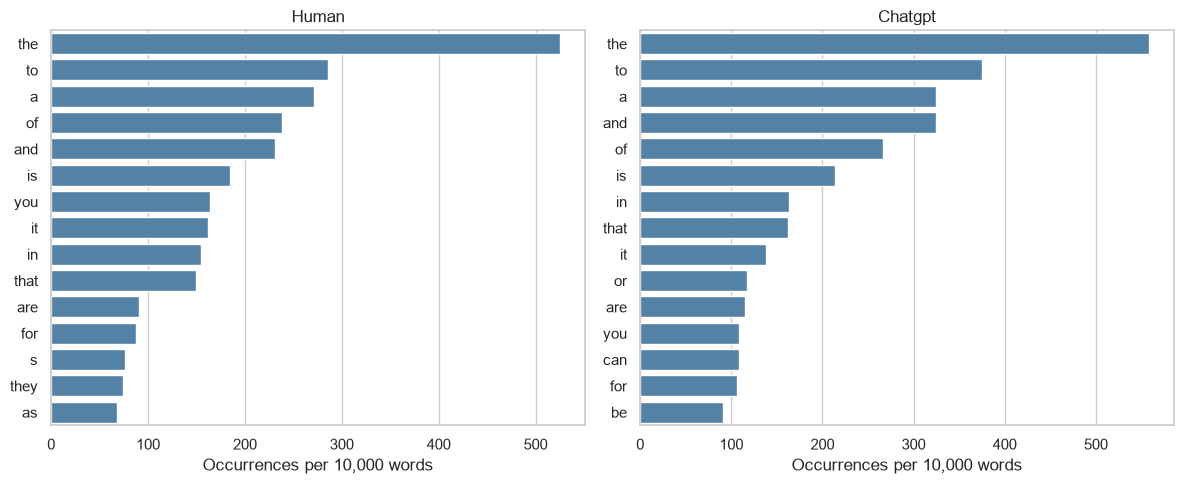

In [5]:
frequency_tables = []
for label in LABELS:
    counts = Counter(word for words in tokens[answers["label"].eq(label)] for word in words)
    table = pd.DataFrame(counts.most_common(15), columns=["word", "count"])
    table["per_10000_words"] = table["count"] / sum(counts.values()) * 10000
    table["label"] = label
    frequency_tables.append(table)

word_frequencies = pd.concat(frequency_tables, ignore_index=True)
display(word_frequencies.round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, label in zip(axes, LABELS):
    subset = word_frequencies[word_frequencies["label"].eq(label)]
    sns.barplot(data=subset, x="per_10000_words", y="word", color="steelblue", ax=ax)
    ax.set_title(label.capitalize())
    ax.set_xlabel("Occurrences per 10,000 words")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Punctuation and Structure

### Compare punctuation and symbol usage

Compare commas, periods, question marks, and other symbols. Counts show total usage per answer; rates per 100 words account for answer length. Bars show the average per-answer rate. Apostrophes include contractions; periods include decimals and abbreviations. Other symbols cover remaining ASCII punctuation and the Unicode ellipsis.

commas        periods        question_marks        exclamation_marks  \
          mean median    mean median           mean median              mean   
label                                                                          
chatgpt   8.51    8.0    7.93    8.0           0.07    0.0              0.14   
human     5.55    3.0    6.73    4.0           0.23    0.0              0.11   

               colons        semicolons        parentheses         \
        median   mean median       mean median        mean median   
label                                                               
chatgpt    0.0   0.68    0.0       0.01    0.0        0.84    0.0   
human      0.0   0.40    0.0       0.11    0.0        1.99    0.0   

        hyphens_dashes        quotes_apostrophes        other_symbols         
                  mean median               mean median          mean median  
label                                                                         
chatgpt           0.79    0.0               2.35    1.0          1.01    0.0  
human             1.05    0.0               3.40    2.0          2.19    0.0

label,chatgpt,human
commas,5.00,4.31
periods,4.66,6.43
question_marks,0.06,0.30
exclamation_marks,0.11,0.12
colons,0.31,0.35
semicolons,0.00,0.09
parentheses,0.46,1.67
hyphens_dashes,0.44,0.73
quotes_apostrophes,1.44,3.03
other_symbols,0.56,2.21


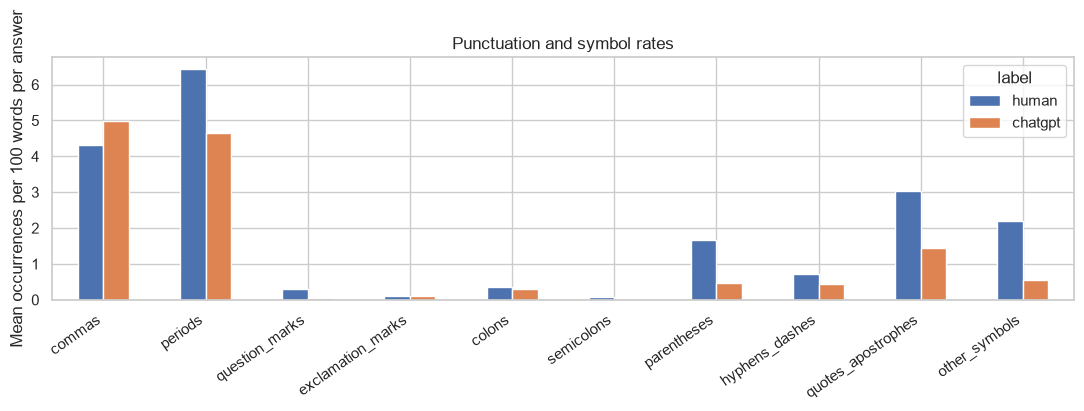

In [6]:
symbols = {
    "commas": ",", "periods": ".", "question_marks": "?", "exclamation_marks": "!",
    "colons": ":", "semicolons": ";", "parentheses": "()", "hyphens_dashes": "-–—",
    "quotes_apostrophes": "\"'‘’“”",
}
covered = set("".join(symbols.values()))
symbols["other_symbols"] = "".join(sorted((set(string.punctuation) | {"…"}) - covered))

for name, characters in symbols.items():
    answers[name] = answers["text"].str.count("[" + re.escape(characters) + "]")
    answers[name + "_per_100_words"] = answers[name] / answers["word_count"].replace(0, float("nan")) * 100

punctuation_columns = list(symbols)
rate_columns = [name + "_per_100_words" for name in symbols]
display(answers.groupby("label")[punctuation_columns].agg(["mean", "median"]).round(2))
punctuation_rates = answers.groupby("label")[rate_columns].mean().T
punctuation_rates.index = punctuation_columns
display(punctuation_rates.round(2))
punctuation_rates[LABELS].plot(kind="bar", figsize=(11, 4))
plt.xlabel("")
plt.ylabel("Mean occurrences per 100 words per answer")
plt.title("Punctuation and symbol rates")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### Compare paragraphs and line breaks

A paragraph is a nonempty block separated by a blank line. The chart shows the percentage of answers with multiple paragraphs. Differences may reflect how the dataset stores text, as well as writing style.

paragraph_count        line_break_count       
                   mean median             mean median
label                                                 
chatgpt            1.76    1.0             1.91    0.0
human              1.01    1.0             0.07    0.0

label
chatgpt    24.85
human       0.06
Name: multiple_paragraphs_percent, dtype: float64

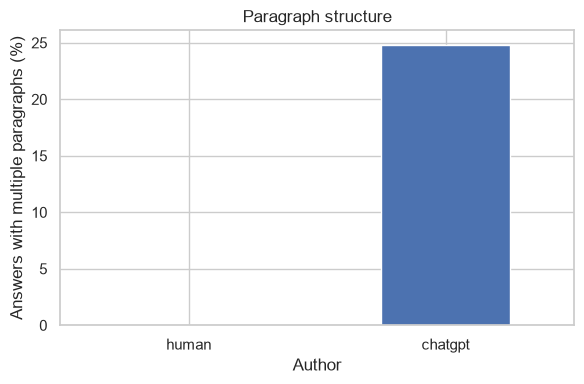

In [7]:
def paragraph_count(text):
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    return sum(bool(block.strip()) for block in re.split(r"\n[ \t]*\n+", text.strip()))

answers["paragraph_count"] = answers["text"].map(paragraph_count)
answers["line_break_count"] = answers["text"].str.count(r"\r\n|\r|\n")
answers["multiple_paragraphs"] = answers["paragraph_count"].gt(1)
display(answers.groupby("label")[["paragraph_count", "line_break_count"]].agg(["mean", "median"]).round(2))
paragraph_percent = answers.groupby("label")["multiple_paragraphs"].mean() * 100
display(paragraph_percent.rename("multiple_paragraphs_percent").round(2))
paragraph_percent.reindex(LABELS).plot(kind="bar", figsize=(6, 4), rot=0)
plt.xlabel("Author")
plt.ylabel("Answers with multiple paragraphs (%)")
plt.title("Paragraph structure")
plt.tight_layout()
plt.show()

### Summarize the comparisons

The results below are calculated from the training answers and cover the comparisons. 

In [24]:
summary = answers.groupby("label").agg(
    median_words=("word_count", "median"),
    mean_sentences=("sentence_count", "mean"),
    median_unique_words=("unique_word_count", "median"),
)
human = summary.loc["human"]
ai = summary.loc["chatgpt"]
display(Markdown(
    f"- Median answer length: **{human.median_words:.0f} words for humans**, **{ai.median_words:.0f} for ChatGPT**. "
    "Length may become a shortcut for a detector.\n"
    f"- Average sentence count: **{human.mean_sentences:.2f} for humans**, **{ai.mean_sentences:.2f} for ChatGPT**.\n"
    f"- Median unique words: **{human.median_unique_words:.0f} for humans**, **{ai.median_unique_words:.0f} for ChatGPT**; "
    "compare this alongside answer length.\n"
    "- Both groups' most frequent words include common function words such as 'the' and 'to'.\n"
    f"- Mean commas per 100 words: **{punctuation_rates.loc['commas', 'human']:.2f} for humans**, "
    f"**{punctuation_rates.loc['commas', 'chatgpt']:.2f} for ChatGPT**.\n"
    f"- Multiple paragraphs: **{paragraph_percent['human']:.2f}% of human answers**, "
    f"**{paragraph_percent['chatgpt']:.2f}% of ChatGPT answers**; stored formatting may affect this difference."
))

- Median answer length: **74 words for humans**, **175 for ChatGPT**. Length may become a shortcut for a detector.
- Average sentence count: **6.65 for humans**, **7.07 for ChatGPT**.
- Median unique words: **54 for humans**, **88 for ChatGPT**; compare this alongside answer length.
- Both groups' most frequent words include common function words such as 'the' and 'to'.
- Mean commas per 100 words: **4.31 for humans**, **5.00 for ChatGPT**.
- Multiple paragraphs: **0.06% of human answers**, **24.85% of ChatGPT answers**; stored formatting may affect this difference.